# Automatic Plain-Language Simplification of Public-Facing Health Information Using Transformer-Based NLP

**Implementation notebook** — MSc Project (COM748)

This notebook implements the methodology described in the project proposal and literature review:

1. Dataset acquisition and inspection (Cochrane-auto)
2. Exploratory data analysis
3. Data cleaning and preprocessing
4. Baseline 1: heuristic rule-based simplification
5. Baseline 2: zero-shot T5-small (no fine-tuning)
6. Main model: fine-tuned T5-small on Cochrane-auto
7. Multi-metric evaluation (readability, overlap, simplification-specific, semantic similarity)
8. Qualitative error analysis
9. Discussion, limitations, and next steps

> **How to use this notebook for your dissertation.** Run all cells top to bottom. Every section prints
> tables and renders charts inline — these are the outputs you should screenshot for the report.
> Figures are also saved automatically to `outputs/figures/` (PNG, 150 dpi) and tables to
> `outputs/tables/` (CSV) so you can re-embed them at full resolution later.
>
> The notebook has a **`DEV_MODE`** switch (next section). Leave it `True` for a fast, first
> end-to-end confirmation run (small sample, few epochs — a few minutes on a laptop). Once you've
> confirmed everything works, set `DEV_MODE = False` and re-run the notebook1 to train on the full dataset.

---


1## 1. Environment & Configuration

We fix random seeds for reproducibility, detect the best available device, and centralise every path and hyperparameter in a single `CONFIG` dictionary. Keeping
training settings explicit here (tokenisation, max sequence length, batch size, learning rate, epochs,
early stopping) matches the documentation requirement set out in the Methodology section of the
proposal, and makes the whole pipeline easy to re-run with different settings later.


In [ ]:
import os, re, json, random, ast, time, math, warnings, gc

# Some networks stall indefinitely with the Hugging Face Hub's "xet" fast-download backend
# (hf_xet package). Disabling it falls back to the standard, more resilient HTTP downloader.
# Must be set before any `transformers`/`huggingface_h1ub` import triggers a download.
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

print("Python / library versions")
print("-" * 40)
import sys, transformers, datasets as hf_datasets
print("python      :", sys.version.split()[0])
print("torch       :", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets    :", hf_datasets.__version__)


Python / library versions
----------------------------------------


python      : 3.13.11
torch       : 2.12.1
transformers: 5.13.0
datasets    : 5.0.0


In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)


Using device: mps


In [3]:
# --------------------------------------------------------------------
# Project paths
# --------------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False and Path.cwd().name == "notebooks" else Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path.cwd().parent

RAW_DATA_DIR       = PROJECT_ROOT / "data" / "raw" / "cochrane-auto" / "data"
PROCESSED_DIR      = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR        = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR         = PROJECT_ROOT / "outputs" / "tables"
MODELS_DIR         = PROJECT_ROOT / "outputs" / "models"

for d in [PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Raw data dir :", RAW_DATA_DIR, "->", "OK" if RAW_DATA_DIR.exists() else "MISSING")


Project root : /Users/johnseun/Desktop/COM748/health-text-simplification
Raw data dir : /Users/johnseun/Desktop/COM748/health-text-simplification/data/raw/cochrane-auto/data -> OK


In [ ]:
# --------------------------------------------------------------------
# CONFIG — every experimental setting lives here. Documented explicitly
# per the Methodology section (tokenisation, max length, batch size,
# learning rate, epochs, early stopping).
# --------------------------------------------------------------------
DEV_MODE = True  # set to False for the full-scale training run.

CONFIG = {
    "model_name": "t5-small",
    "task_prefix": "simplify: ",
    "max_input_length": 128,
    "max_target_length": 128,

    # DEV_MODE uses a small subset + fewer epochs
    "dev_train_samples": 800,
    "dev_val_samples": 150,
    "dev_epochs": 3,

    "full_epochs": 8,

    "batch_size": 4,
    "gradient_accumulation_steps": 2,  # effective train batch size = batch_size * this = 8
    "eval_batch_size": 4,
    "learning_rate": 3e-4,
    "weight_decay": 0.01,
    "early_stopping_patience": 2,

    "generation_max_new_tokens": 128,
    "generation_num_beams": 4,

    "bertscore_model_type": "distilbert-base-uncased",  # lightweight; swap for "roberta-large" (original BERTScore paper) for final results
    "n_qualitative_examples": 8,
}

print(json.dumps(CONFIG, indent=2))
print("\nDEV_MODE =", DEV_MODE, "-> epochs:", CONFIG["dev_epochs"] if DEV_MODE else CONFIG["full_epochs"])


{
  "model_name": "t5-small",
  "task_prefix": "simplify: ",
  "max_input_length": 128,
  "max_target_length": 128,
  "dev_train_samples": 800,
  "dev_val_samples": 150,
  "dev_epochs": 3,
  "full_epochs": 8,
  "batch_size": 4,
  "gradient_accumulation_steps": 2,
  "eval_batch_size": 4,
  "learning_rate": 0.0003,
  "weight_decay": 0.01,
  "early_stopping_patience": 2,
  "generation_max_new_tokens": 128,
  "generation_num_beams": 4,
  "bertscore_model_type": "distilbert-base-uncased",
  "n_qualitative_examples": 8
}

DEV_MODE = True -> epochs: 3


## 2. Dataset Acquisition and Inspection

**Primary dataset:** *Cochrane-auto* (Bakker & Kamps, 2024). A11n aligned corpus linking biomedical
abstracts (technical) with Cochrane Plain Language Summaries (lay), aligned at sentence, paragraph,
and document level using a neural CRF alignment model.

- Paper: <https://aclanthology.org/2024.tsar-1.5/> (DOI: 10.18653/v1/2024.tsar-1.5)
- Data & code: <https://github.com/JanB100/cochrane-auto>

The repository ships pre-computed sentence-, paragraph-, and document-level CSVs, already split into
train/validation/test. We work at **sentence level** (`cochraneauto_sents_{split}.csv`), which keeps
sequence lengths manageable for T5-small on modest hardware, per the Methodology section.

Each row aligns one *complex* (technical abstract) sentence with zero or more *simple* (lay summary)
sentences, tagged with a **rewrite-operation label**:

| label | meaning |
|---|---|
| `rephrase` | complex sentence maps to one simplified sentence |
| `split` | complex sentence's content is spread across multiple simplified sentences |
| `merge` | this complex sentence is merged with others into one simplified sentence |
| `delete` | complex sentence is dropped entirely from the lay summary |
| `ignore` / `none` | no reliable alignment could be established |

We build **(complex → simple) training pairs** from every row whose `simple` field is non-empty. This naturally captures `rephrase`, `split`, and the "carrying" row of a `merge` group, while
correctly excluding sentences that were deleted or left unaligned.


In [5]:
# --------------------------------------------------------------------
# Fallback: clone the dataset if it isn't already present in data/raw
# --------------------------------------------------------------------
import subprocess

if not RAW_DATA_DIR.exists():
    print("Cochrane-auto not found locally — cloning from GitHub ...")
    repo_dir = PROJECT_ROOT / "data" / "raw" / "cochrane-auto"
    repo_dir.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        ["git", "clone", "--depth", "1", "https://github.com/JanB100/cochrane-auto.git", str(repo_dir)],
        check=True,
    )
else:
    print("Cochrane-auto found locally at:", RAW_DATA_DIR)


Cochrane-auto found locally at: /Users/johnseun/Desktop/COM748/health-text-simplification/data/raw/cochrane-auto/data


In [6]:
def load_sentence_split(split: str) -> pd.DataFrame:
    '''Load one sentence-level Cochrane-auto split (train/val/test).'''
    path = RAW_DATA_DIR / f"cochraneauto_sents_{split}.csv"
    df = pd.read_csv(path)
    return df

raw_train = load_sentence_split("train")
raw_val   = load_sentence_split("val")
raw_test  = load_sentence_split("test")

print("Raw sentence-level rows:")
for name, df in [("train", raw_train), ("val", raw_val), ("test", raw_test)]:
    print(f"  {name:5s}: {len(df):6d} rows")

raw_train.head(3)


Raw sentence-level rows:
  train:  11510 rows
  val  :   1697 rows
  test :   1512 rows


,pair_id,para_id,sent_id,complex,label,simple,simp_sent_id,doc_pos,doc_quint,doc_len
0,CD012936,0,0,Three studies (146 participants) met our selec...,rephrase,['Three studies involving 146 participants wer...,0,0.090909,1,11
1,CD012936,0,1,"Two studies compared multidisciplinary, fast-t...",delete,[],1,0.181818,1,11
2,CD012936,0,2,Two were RCTs with parallel design (total 94 p...,delete,[],1,0.272727,2,11


          train  val  test
label                     
rephrase   5239  758   667
split       521   58    77
merge       365   64    43
delete     4063  592   537
ignore      982  168   148
none        340   57    40


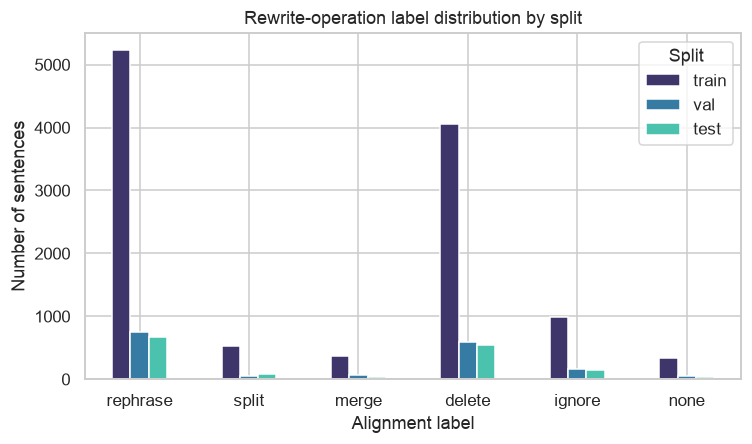

In [7]:
# --------------------------------------------------------------------
# Label distribution across splits (before pair extraction)
# --------------------------------------------------------------------
label_counts = pd.DataFrame({
    "train": raw_train["label"].value_counts(),
    "val":   raw_val["label"].value_counts(),
    "test":  raw_test["label"].value_counts(),
}).fillna(0).astype(int)
label_counts = label_counts.loc[["rephrase", "split", "merge", "delete", "ignore", "none"]]
print(label_counts)

fig, ax = plt.subplots(figsize=(7, 4.2))
label_counts.plot(kind="bar", ax=ax, color=sns.color_palette("mako", 3))
ax.set_title("Rewrite-operation label distribution by split")
ax.set_xlabel("Alignment label")
ax.set_ylabel("Number of sentences")
ax.legend(title="Split")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_label_distribution.png", dpi=150)
plt.show()


## 3. Exploratory Data Analysis

Before modelling, we need to understand *what kind of rewriting problem* the model is being asked to
solve: how long are the source and target sentences, how much does the lay version compress or expand
the technical one, and what do a few real aligned pairs actually look like.


In [8]:
def parse_simple_field(raw_value):
    '''The 'simple' column is stored as a stringified Python list, e.g. "['a sentence.']".'''
    try:
        value = ast.literal_eval(raw_value)
        return value if isinstance(value, list) else []
    except (ValueError, SyntaxError):
        return []


def extract_pairs(df: pd.DataFrame) -> pd.DataFrame:
    '''Build (complex, simple) sentence pairs from rows with a non-empty aligned target.'''
    df = df.copy()
    df["simple_list"] = df["simple"].apply(parse_simple_field)
    df = df[df["simple_list"].map(len) > 0].reset_index(drop=True)
    df["simple"] = df["simple_list"].apply(lambda lst: " ".join(s.strip() for s in lst).strip())
    df["complex"] = df["complex"].astype(str).str.strip()
    return df[["pair_id", "label", "complex", "simple"]]

pairs_train = extract_pairs(raw_train)
pairs_val   = extract_pairs(raw_val)
pairs_test  = extract_pairs(raw_test)

print("Aligned (complex -> simple) pairs extracted:")
for name, df in [("train", pairs_train), ("val", pairs_val), ("test", pairs_test)]:
    print(f"  {name:5s}: {len(df):6d} pairs")

pairs_train.sample(5, random_state=SEED)


Aligned (complex -> simple) pairs extracted:
  train:   7082 pairs
  val  :   1041 pairs
  test :    932 pairs


,pair_id,label,complex,simple
2991,CD006522,ignore,Two trials comparing a bridging (of the wrist)...,Two trials comparing a bridging (of the wrist)...
6000,CD009221,rephrase,For modafinil and atomoxetine no positive effe...,"More people taking modafinil, atomoxetine and ..."
711,CD007472,ignore,There were no significant differences in any o...,There was no significant difference in any of ...
6283,CD002784,split,We included five trials with a total of 1292 p...,Authors of the review identified five controll...
6069,CD006929,merge,"For fourteen studies, FA was just one aspect o...","Most evaluated broad programmes of care, where..."


In [9]:
# --------------------------------------------------------------------
# Length distributions and compression ratio
# --------------------------------------------------------------------
def add_length_stats(df):
    df = df.copy()
    df["complex_words"] = df["complex"].str.split().str.len()
    df["simple_words"] = df["simple"].str.split().str.len()
    df["compression_ratio"] = df["simple_words"] / df["complex_words"]
    return df

pairs_train = add_length_stats(pairs_train)
pairs_val   = add_length_stats(pairs_val)
pairs_test  = add_length_stats(pairs_test)

eda_summary = pairs_train[["complex_words", "simple_words", "compression_ratio"]].describe().round(2)
print(eda_summary)
eda_summary.to_csv(TABLES_DIR / "eda_summary_train.csv")


       complex_words  simple_words  compression_ratio
count        7082.00       7082.00            7082.00
mean           24.86         23.59               1.13
std            15.66         12.88               0.72
min             1.00          3.00               0.06
25%            15.00         15.00               0.73
50%            21.00         21.00               1.00
75%            31.00         29.00               1.27
max           186.00        145.00               9.75


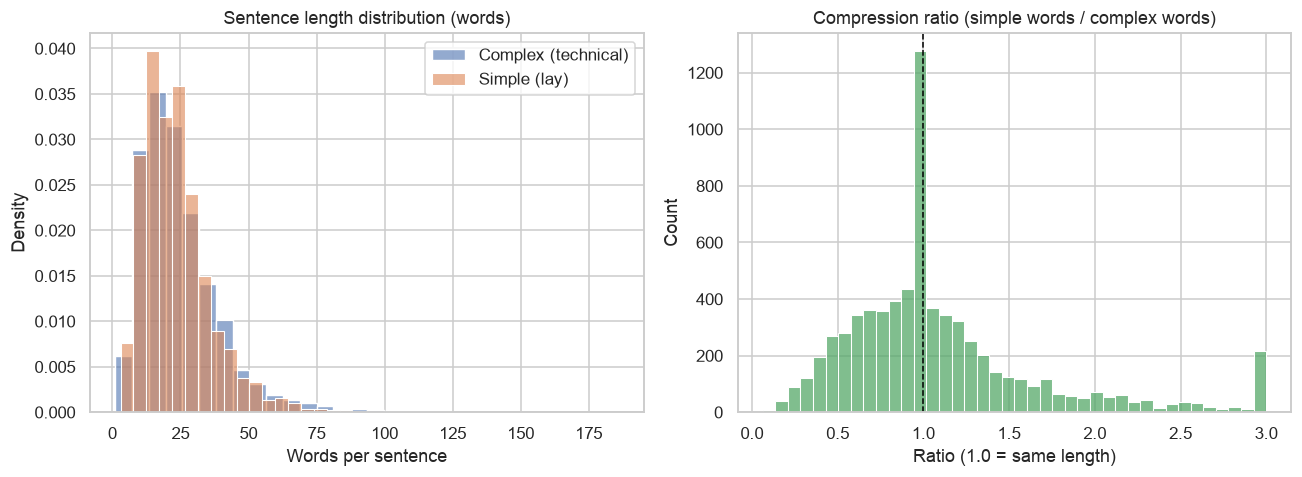

Median compression ratio: 1.00
Share of pairs where the lay sentence is LONGER than the technical one: 41.1%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(pairs_train["complex_words"], bins=30, color="#4c72b0", label="Complex (technical)", ax=axes[0], stat="density", alpha=0.6)
sns.histplot(pairs_train["simple_words"], bins=30, color="#dd8452", label="Simple (lay)", ax=axes[0], stat="density", alpha=0.6)
axes[0].set_title("Sentence length distribution (words)")
axes[0].set_xlabel("Words per sentence")
axes[0].legend()

sns.histplot(pairs_train["compression_ratio"].clip(0, 3), bins=40, color="#55a868", ax=axes[1])
axes[1].axvline(1.0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Compression ratio (simple words / complex words)")
axes[1].set_xlabel("Ratio (1.0 = same length)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_length_and_compression.png", dpi=150)
plt.show()

print(f"Median compression ratio: {pairs_train['compression_ratio'].median():.2f}")
print(f"Share of pairs where the lay sentence is LONGER than the technical one: "
      f"{(pairs_train['compression_ratio'] > 1).mean():.1%}")


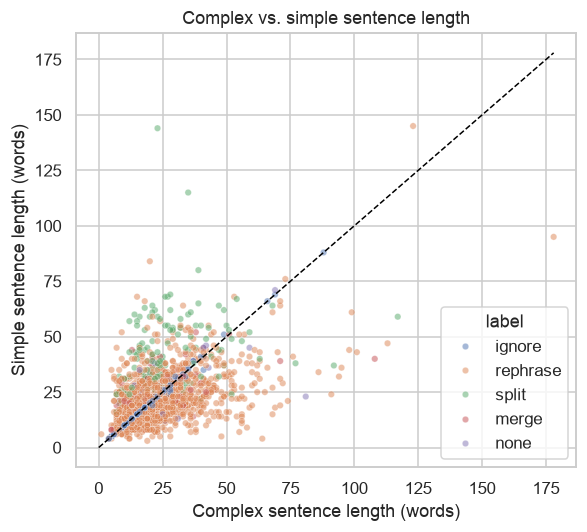

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 5))
sample = pairs_train.sample(min(1500, len(pairs_train)), random_state=SEED)
sns.scatterplot(data=sample, x="complex_words", y="simple_words", hue="label", alpha=0.5, s=18, ax=ax)
lims = [0, max(sample["complex_words"].max(), sample["simple_words"].max())]
ax.plot(lims, lims, color="black", linestyle="--", linewidth=1)
ax.set_title("Complex vs. simple sentence length")
ax.set_xlabel("Complex sentence length (words)")
ax.set_ylabel("Simple sentence length (words)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_complex_vs_simple_scatter.png", dpi=150)
plt.show()


In [12]:
# --------------------------------------------------------------------
# Manual inspection: a few real aligned pairs per rewrite-operation type
# --------------------------------------------------------------------
for label in ["rephrase", "split", "merge"]:
    print("=" * 100)
    print(f"LABEL: {label}")
    print("=" * 100)
    sub = pairs_train[pairs_train["label"] == label].sample(2, random_state=SEED)
    for _, row in sub.iterrows():
        print("COMPLEX:", row["complex"])
        print("SIMPLE :", row["simple"])
        print("-" * 100)


LABEL: rephrase
COMPLEX: Programmes to improve community ambulation consisted of walking practice in a variety of settings and environments in the community, or an indoor activity that mimicked community walking (including virtual reality or mental imagery).
SIMPLE : Programmes to improve community ambulation consisted of walking practice in a variety of settings and environments in the community (three studies), or an activity indoors that mimicked community walking (three studies).
----------------------------------------------------------------------------------------------------
COMPLEX: The only significant differences between groups related to uterine hyperstimulation (without fetal heart rate changes), and results were not consistent in the two trials.
SIMPLE : The evidence on uterine hyperstimulation without fetal heart rate changes was not consistent.
----------------------------------------------------------------------------------------------------
LABEL: split
COMPLEX: For 

**Notes for the dissertation (TODO: fill in after reviewing the printed examples and charts above):**

- Does the lay version mostly *shorten* the technical sentence, or does it sometimes *add* explanatory
  context that is not literally present in the source (audience adaptation rather than pure compression)?
- Are there systematic vocabulary differences (e.g. statistical/clinical terms on the complex side)?
- Do `split` pairs suggest that acceptable simplification often needs more than one output sentence?


## 4. Data Cleaning and Preprocessing

Preprocessing stays deliberately conservative here: health text is a domain where aggressive cleaning
can silently discard clinically meaningful wording. We only remove genuine noise (exact duplicates,
empty fields, whitespace artefacts) and **flag** rather than silently drop unusually long or short
pairs, so every decision is logged and traceable back to the original aligned pair.


In [13]:
def clean_pairs(df: pd.DataFrame, min_words: int = 3, max_words: int = 120):
    log = {"input_rows": len(df)}
    df = df.copy()

    # Normalise whitespace
    df["complex"] = df["complex"].str.replace(r"\s+", " ", regex=True).str.strip()
    df["simple"]  = df["simple"].str.replace(r"\s+", " ", regex=True).str.strip()

    # Drop exact duplicate pairs
    before = len(df)
    df = df.drop_duplicates(subset=["complex", "simple"]).reset_index(drop=True)
    log["duplicates_removed"] = before - len(df)

    # Drop empty fields
    before = len(df)
    df = df[(df["complex"].str.len() > 0) & (df["simple"].str.len() > 0)].reset_index(drop=True)
    log["empty_removed"] = before - len(df)

    # Flag (but keep) extreme lengths for transparency
    df["complex_words"] = df["complex"].str.split().str.len()
    df["simple_words"]  = df["simple"].str.split().str.len()
    too_short = ((df["complex_words"] < min_words) | (df["simple_words"] < min_words))
    too_long  = (df["complex_words"] > max_words)
    log["flagged_too_short"] = int(too_short.sum())
    log["flagged_too_long"]  = int(too_long.sum())

    # For modelling we drop the too-short (likely fragments/noise) but keep long ones
    # (truncation is handled later at tokenisation time, not by discarding data).
    df = df[~too_short].reset_index(drop=True)
    log["output_rows"] = len(df)
    return df, log

clean_train, log_train = clean_pairs(pairs_train)
clean_val,   log_val   = clean_pairs(pairs_val)
clean_test,  log_test  = clean_pairs(pairs_test)

preprocessing_log = {"train": log_train, "val": log_val, "test": log_test}
print(json.dumps(preprocessing_log, indent=2))

with open(PROCESSED_DIR / "preprocessing_log.json", "w") as f:
    json.dump(preprocessing_log, f, indent=2)


{
  "train": {
    "input_rows": 7082,
    "duplicates_removed": 6,
    "empty_removed": 0,
    "flagged_too_short": 1,
    "flagged_too_long": 14,
    "output_rows": 7075
  },
  "val": {
    "input_rows": 1041,
    "duplicates_removed": 1,
    "empty_removed": 0,
    "flagged_too_short": 0,
    "flagged_too_long": 2,
    "output_rows": 1040
  },
  "test": {
    "input_rows": 932,
    "duplicates_removed": 0,
    "empty_removed": 0,
    "flagged_too_short": 0,
    "flagged_too_long": 2,
    "output_rows": 932
  }
}


In [14]:
# Persist processed splits (original Cochrane-auto split boundaries are respected)
clean_train.to_csv(PROCESSED_DIR / "train.csv", index=False)
clean_val.to_csv(PROCESSED_DIR / "val.csv", index=False)
clean_test.to_csv(PROCESSED_DIR / "test.csv", index=False)

print("Final processed pair counts:")
print(f"  train: {len(clean_train)}")
print(f"  val  : {len(clean_val)}")
print(f"  test : {len(clean_test)}")


Final processed pair counts:
  train: 7075
  val  : 1040
  test : 932


## 5. Baseline 1: Heuristic Rule-Based Simplifier

A learned model should be shown to outperform something simpler than chance or trivial copying. This
heuristic baseline is intentionally modest: it performs (a) a small set of low-risk lexical
substitutions of common biomedical/statistical terms, and (b) punctuation-aware splitting of very long
sentences at safe boundaries (coordinating conjunctions, semicolons).

We deliberately **do not** strip statistical detail in parentheses (e.g. confidence intervals, effect
sizes) removing it would risk exactly the kind of meaning loss the proposal flags as a safety concern
in health communication. The baseline is allowed to be a little clumsy; that is informative in itself.


In [15]:
# A small, conservative, low-risk lexical substitution table.
# Terms were chosen because their plain-language equivalent is essentially synonymous
# in this context (not an approximation that could change clinical meaning).
LEXICON = {
    r"\bparticipants\b": "people",
    r"\brandomised controlled trials?\b": "fair comparison studies",
    r"\bRCTs?\b": "fair comparison studies",
    r"\badverse events?\b": "side effects",
    r"\bmortality\b": "death",
    r"\bmorbidity\b": "illness",
    r"\befficacy\b": "how well it works",
    r"\bstatistically significant\b": "a real difference (unlikely due to chance)",
    r"\bclinically significant\b": "having a meaningful effect on health",
    r"\bmeta-analysis\b": "combined analysis of several studies",
    r"\bsystematic review\b": "a review that combines results from many studies",
    r"\bconfidence interval\b": "likely range of results",
    r"\bheterogeneity\b": "differences between study results",
    r"\bcohort\b": "group of people followed over time",
    r"\bplacebo\b": "dummy treatment",
    r"\bmyocardial infarction\b": "heart attack",
    r"\bhypertension\b": "high blood pressure",
    r"\bhypotension\b": "low blood pressure",
    r"\bcontraindicated\b": "not recommended",
    r"\bprophylaxis\b": "prevention",
    r"\betiology\b": "cause",
    r"\basymptomatic\b": "showing no symptoms",
    r"\bexacerbat(e|ion|ed)\b": "worsen",
    r"\bpost[- ]?operative\b": "after surgery",
    r"\bpre[- ]?operative\b": "before surgery",
}
COMPILED_LEXICON = [(re.compile(pat, flags=re.IGNORECASE), repl) for pat, repl in LEXICON.items()]

SPLIT_CONJUNCTIONS = [" ; ", " however, ", " whereas ", " while ", " although "]
LONG_SENTENCE_WORD_THRESHOLD = 28


def lexical_substitute(text: str) -> str:
    for pattern, replacement in COMPILED_LEXICON:
        text = pattern.sub(replacement, text)
    return text


def split_long_sentence(text: str) -> str:
    if len(text.split()) <= LONG_SENTENCE_WORD_THRESHOLD:
        return text
    for conj in SPLIT_CONJUNCTIONS:
        if conj in text.lower():
            idx = text.lower().find(conj)
            first, rest = text[:idx].strip(), text[idx + len(conj):].strip()
            if first and rest:
                first = first if first.endswith((".", "!", "?")) else first + "."
                rest = rest[0].upper() + rest[1:] if rest else rest
                return f"{first} {rest}"
    return text  # no safe split point found; leave as-is rather than risk breaking the sentence


def heuristic_simplify(text: str) -> str:
    text = lexical_substitute(text)
    text = split_long_sentence(text)
    return text


In [16]:
clean_test["heuristic_output"] = clean_test["complex"].apply(heuristic_simplify)

print("Example heuristic transformations:\n")
for _, row in clean_test.sample(5, random_state=SEED).iterrows():
    print("SOURCE   :", row["complex"])
    print("HEURISTIC:", row["heuristic_output"])
    print("REFERENCE:", row["simple"])
    print("-" * 100)


Example heuristic transformations:



SOURCE   : The eight randomised clinical trials have a high risk of bias.
HEURISTIC: The eight randomised clinical trials have a high risk of bias.
REFERENCE: Based on eight randomised clinical trials of high risk of bias, the administration of ursodeoxycholic acid to patients with primary sclerosing cholangitis did not significantly reduce mortality, hepatic decompensation, need for liver transplantation, liver histological deterioration, or radiological deterioration compared with placebo or no intervention.
----------------------------------------------------------------------------------------------------
SOURCE   : Statistically significant differences were not detected in any of the comparisons and outcomes.
HEURISTIC: a real difference (unlikely due to chance) differences were not detected in any of the comparisons and outcomes.
REFERENCE: In each individual trial no significant differences were detected with regard to patients' survival after transplantation, HBV recurrence, or

## 6. Baseline 2: Zero-Shot T5-small (No Fine-Tuning)

Before fine-tuning, we check what an *off-the-shelf* T5-small produces when simply prompted with the
`"simplify: "` task prefix. This isolates how much of the eventual improvement actually comes from
domain-specific fine-tuning on Cochrane-auto, rather than from the transformer architecture alone.


In [17]:
from transformers import T5Tokenizer, T5ForConditionalGeneration, AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
zero_shot_model = AutoModelForSeq2SeqLM.from_pretrained(CONFIG["model_name"]).to(DEVICE)
zero_shot_model.eval()

@torch.no_grad()
def generate_simplifications(model, tokenizer, texts, batch_size=16):
    outputs = []
    prefixed = [CONFIG["task_prefix"] + t for t in texts]
    for i in range(0, len(prefixed), batch_size):
        batch = prefixed[i:i + batch_size]
        enc = tokenizer(batch, return_tensors="pt", padding=True, truncation=True,
                         max_length=CONFIG["max_input_length"]).to(DEVICE)
        gen = model.generate(
            **enc,
            max_new_tokens=CONFIG["generation_max_new_tokens"],
            num_beams=CONFIG["generation_num_beams"],
        )
        outputs.extend(tokenizer.batch_decode(gen, skip_special_tokens=True))
    return outputs


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

In [18]:
# Evaluate the zero-shot baseline on a manageable sample of the test set
eval_sample_size = 150 if DEV_MODE else len(clean_test)
eval_df = clean_test.sample(min(eval_sample_size, len(clean_test)), random_state=SEED).reset_index(drop=True)

eval_df["zeroshot_output"] = generate_simplifications(zero_shot_model, tokenizer, eval_df["complex"].tolist())
eval_df["heuristic_output"] = eval_df["complex"].apply(heuristic_simplify)

print("Example zero-shot T5-small outputs:\n")
for _, row in eval_df.sample(3, random_state=SEED).iterrows():
    print("SOURCE   :", row["complex"])
    print("ZERO-SHOT:", row["zeroshot_output"])
    print("REFERENCE:", row["simple"])
    print("-" * 100)

del zero_shot_model
gc.collect()
if DEVICE.type == "mps":
    torch.mps.empty_cache()
elif DEVICE.type == "cuda":
    torch.cuda.empty_cache()


Example zero-shot T5-small outputs:

SOURCE   : The single large RCT (ADOPT - A Diabetes Outcomes Progression Trial) indicated increased cardiovascular risk.
ZERO-SHOT: Einfacher: Die Single Large RCT (ADOPT - A Diabetes Outcomes Progression Trial) zeigte eine erhöhte Herz-Kreislauf-Risiko.
REFERENCE: The single large randomised controlled trial showed evidence of raised cardiovascular risk after rosiglitazone treatment.
----------------------------------------------------------------------------------------------------
SOURCE   : The evidence in this review is therefore weak, and the exact prevalence of severe fatigue after treatment for childhood cancer remains to be determined.
ZERO-SHOT: Einfacher: Die Beweise in dieser Studie sind daher schwach, und die genaue Prävalence der severe fatigue after treatment for childhood cancer bleibt zu ermitteln.
REFERENCE: The evidence to address our review question is therefore weak. The occurrence of severe fatigue after treatment for childhood

## 7. Main Model: Fine-Tuning T5-small on Cochrane-auto

**Documented training settings** (per the Methodology section):

| Setting | Value |
|---|---|
| Base model | `t5-small` (encoder-decoder transformer, ~60M parameters) |
| Task prefix | `"simplify: "` |
| Max input length | 128 tokens |
| Max target length | 128 tokens |
| Batch size | 4 (train) x 2 gradient-accumulation steps = effective 8, 4 (eval). This is kept small deliberately for machines with limited unified memory |
| Learning rate | 3e-4 (AdamW) |
| Epochs | 3 (DEV_MODE) / 8 (full run), with early stopping (patience = 2) on validation loss |
| Tokeniser | T5 SentencePiece tokenizer |

BART-base is noted in the proposal as an alternative architecture. The training function below is
model-agnostic (`build_and_finetune(model_name=...)`), so the same pipeline can fine-tune
`facebook/bart-base` by changing one argument if T5-small's capacity proves limiting.


In [19]:
from datasets import Dataset, DatasetDict

def to_hf_dataset(df: pd.DataFrame) -> Dataset:
    return Dataset.from_pandas(df[["complex", "simple"]].reset_index(drop=True))

if DEV_MODE:
    train_subset = clean_train.sample(min(CONFIG["dev_train_samples"], len(clean_train)), random_state=SEED)
    val_subset   = clean_val.sample(min(CONFIG["dev_val_samples"], len(clean_val)), random_state=SEED)
else:
    train_subset = clean_train
    val_subset   = clean_val

raw_datasets = DatasetDict({
    "train": to_hf_dataset(train_subset),
    "validation": to_hf_dataset(val_subset),
})
print(raw_datasets)


DatasetDict({
    train: Dataset({
        features: ['complex', 'simple'],
        num_rows: 800
    })
    validation: Dataset({
        features: ['complex', 'simple'],
        num_rows: 150
    })
})


In [20]:
def preprocess_function(examples, tokenizer):
    inputs = [CONFIG["task_prefix"] + x for x in examples["complex"]]
    model_inputs = tokenizer(inputs, max_length=CONFIG["max_input_length"], truncation=True)
    labels = tokenizer(text_target=examples["simple"], max_length=CONFIG["max_target_length"], truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_datasets = raw_datasets.map(
    lambda ex: preprocess_function(ex, tokenizer),
    batched=True,
    remove_columns=["complex", "simple"],
)
tokenized_datasets


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 800
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 150
    })
})

In [21]:
from transformers import (
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
)

model = AutoModelForSeq2SeqLM.from_pretrained(CONFIG["model_name"]).to(DEVICE)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

num_epochs = CONFIG["dev_epochs"] if DEV_MODE else CONFIG["full_epochs"]
run_name = "t5-small-cochrane-simplify" + ("-dev" if DEV_MODE else "-full")

training_args = Seq2SeqTrainingArguments(
    output_dir=str(MODELS_DIR / run_name),
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    learning_rate=CONFIG["learning_rate"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["eval_batch_size"],
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
    weight_decay=CONFIG["weight_decay"],
    num_train_epochs=num_epochs,
    predict_with_generate=False,
    logging_steps=25,
    report_to=[],
    use_cpu=(DEVICE.type == "cpu"),
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=CONFIG["early_stopping_patience"])],
)

print(f"Training {CONFIG['model_name']} for up to {num_epochs} epoch(s) on {len(tokenized_datasets['train'])} "
      f"examples (DEV_MODE={DEV_MODE}), device={DEVICE} ...")
train_result = trainer.train()


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Training t5-small for up to 3 epoch(s) on 800 examples (DEV_MODE=True), device=mps ...


Epoch,Training Loss,Validation Loss
1,4.265647,2.142305
2,3.991026,2.099223
3,3.695691,2.102675


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


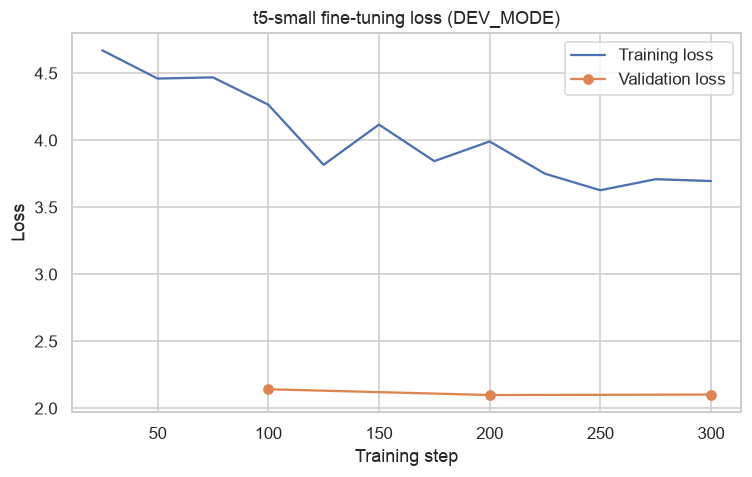

In [22]:
# --------------------------------------------------------------------
# Training / validation loss curve
# --------------------------------------------------------------------
history = pd.DataFrame(trainer.state.log_history)
train_loss = history[history["loss"].notna()][["step", "loss"]] if "loss" in history else pd.DataFrame()
eval_loss  = history[history.get("eval_loss").notna()][["step", "eval_loss"]] if "eval_loss" in history else pd.DataFrame()

fig, ax = plt.subplots(figsize=(7, 4.5))
if not train_loss.empty:
    ax.plot(train_loss["step"], train_loss["loss"], label="Training loss", color="#4c72b0")
if not eval_loss.empty:
    ax.plot(eval_loss["step"], eval_loss["eval_loss"], label="Validation loss", color="#dd8452", marker="o")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.set_title(f"{CONFIG['model_name']} fine-tuning loss ({'DEV_MODE' if DEV_MODE else 'full run'})")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_training_loss_curve.png", dpi=150)
plt.show()


In [ ]:
# Persist the fine-tuned model + tokenizer for later reuse or for further evaluation
final_model_dir = MODELS_DIR / run_name / "final"
trainer.save_model(str(final_model_dir))
tokenizer.save_pretrained(str(final_model_dir))
print("Fine-tuned model saved to:", final_model_dir)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model saved to: /Users/johnseun/Desktop/COM748/health-text-simplification/outputs/models/t5-small-cochrane-simplify-dev/final


In [24]:
# --------------------------------------------------------------------
# Generate simplifications with the fine-tuned model on the same evaluation sample
# --------------------------------------------------------------------
finetuned_model = model
finetuned_model.eval()

eval_df["finetuned_output"] = generate_simplifications(finetuned_model, tokenizer, eval_df["complex"].tolist())

print("Example fine-tuned T5-small outputs:\n")
for _, row in eval_df.sample(3, random_state=SEED).iterrows():
    print("SOURCE    :", row["complex"])
    print("FINE-TUNED:", row["finetuned_output"])
    print("REFERENCE :", row["simple"])
    print("-" * 100)


Example fine-tuned T5-small outputs:

SOURCE    : The single large RCT (ADOPT - A Diabetes Outcomes Progression Trial) indicated increased cardiovascular risk.
FINE-TUNED: The single large RCT (ADOPT - A Diabetes Outcomes Progression Trial) indicated increased cardiovascular risk.
REFERENCE : The single large randomised controlled trial showed evidence of raised cardiovascular risk after rosiglitazone treatment.
----------------------------------------------------------------------------------------------------
SOURCE    : The evidence in this review is therefore weak, and the exact prevalence of severe fatigue after treatment for childhood cancer remains to be determined.
FINE-TUNED: The evidence in this review is therefore weak, and the exact prevalence of severe fatigue after treatment for childhood cancer remains to be determined.
REFERENCE : The evidence to address our review question is therefore weak. The occurrence of severe fatigue after treatment for childhood cancer remains 

## 8. Evaluation Metrics

Automatic evaluation combines four families of measure, each capturing a different aspect of
simplification quality, per the Methodology and evaluation-literature discussion above.

### Readability metrics

**Flesch Reading Ease**

$$FRE = 206.835 - 1.015\left(\dfrac{\text{total words}}{\text{total sentences}}\right) - 84.6\left(\dfrac{\text{total syllables}}{\text{total words}}\right)$$

Higher is easier to read (0–100 scale).

**Flesch–Kincaid Grade Level**

$$FKGL = 0.39\left(\dfrac{\text{total words}}{\text{total sentences}}\right) + 11.8\left(\dfrac{\text{total syllables}}{\text{total words}}\right) - 15.59$$

Approximates the US school-grade level required to understand the text.

**SMOG Index**

$$SMOG = 1.0430\sqrt{\text{polysyllable count} \times \dfrac{30}{\text{number of sentences}}} + 3.1291$$

### Overlap-based metrics

**BLEU** (Papineni et al., 2002)

$$BLEU = BP \cdot \exp\left(\sum_{n=1}^{N} w_n \log p_n\right), \qquad BP = \min\!\left(1,\ e^{1 - r/c}\right)$$

**ROUGE-N** (Lin, 2004)

$$ROUGE\text{-}N = \dfrac{\sum_{S \in \text{Refs}} \sum_{\text{gram}_n \in S} \text{Count}_{\text{match}}(\text{gram}_n)}{\sum_{S \in \text{Refs}} \sum_{\text{gram}_n \in S} \text{Count}(\text{gram}_n)}$$

### Simplification-specific metric

**SARI** (Xu et al., 2016) rewards words correctly **added**, **kept**, and **deleted** relative to
the source and reference(s):

$$SARI = \frac{1}{3}\left(F_{\text{add}} + F_{\text{keep}} + P_{\text{delete}}\right)$$

### Meaning-preservation metric

**BERTScore** (Zhang et al., 2020) contextual-embedding similarity between candidate and reference:

$$P_{\text{BERT}} = \frac{1}{|\hat{x}|}\sum_{\hat{x}_j \in \hat{x}} \max_{x_i \in x} \mathbf{x}_i^{\top}\hat{\mathbf{x}}_j
\qquad
R_{\text{BERT}} = \frac{1}{|x|}\sum_{x_i \in x} \max_{\hat{x}_j \in \hat{x}} \mathbf{x}_i^{\top}\hat{\mathbf{x}}_j
\qquad
F_{\text{BERT}} = 2\cdot\frac{P_{\text{BERT}} \cdot R_{\text{BERT}}}{P_{\text{BERT}} + R_{\text{BERT}}}$$


In [25]:
import textstat
import sacrebleu
from rouge_score import rouge_scorer
import evaluate as hf_evaluate
from bert_score import score as bertscore_score

sari_metric = hf_evaluate.load("sari")
rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

print("Metric libraries loaded: textstat, sacrebleu, rouge_score, evaluate(sari), bert_score")


Metric libraries loaded: textstat, sacrebleu, rouge_score, evaluate(sari), bert_score


In [26]:
def readability_metrics(texts):
    texts = [t for t in texts if isinstance(t, str) and t.strip()]
    return {
        "flesch_reading_ease": np.mean([textstat.flesch_reading_ease(t) for t in texts]),
        "flesch_kincaid_grade": np.mean([textstat.flesch_kincaid_grade(t) for t in texts]),
        "smog_index": np.mean([textstat.smog_index(t) for t in texts]),
    }


def overlap_and_simplification_metrics(sources, predictions, references):
    bleu = sacrebleu.corpus_bleu(predictions, [references]).score

    rouge_scores = [rouge.score(ref, pred) for pred, ref in zip(predictions, references)]
    rouge1 = np.mean([s["rouge1"].fmeasure for s in rouge_scores])
    rouge2 = np.mean([s["rouge2"].fmeasure for s in rouge_scores])
    rougeL = np.mean([s["rougeL"].fmeasure for s in rouge_scores])

    sari = sari_metric.compute(sources=sources, predictions=predictions, references=[[r] for r in references])["sari"]

    return {"bleu": bleu, "rouge1": rouge1, "rouge2": rouge2, "rougeL": rougeL, "sari": sari}


def meaning_preservation_metrics(predictions, references):
    P, R, F1 = bertscore_score(
        predictions, references, lang="en",
        model_type=CONFIG["bertscore_model_type"], verbose=False,
    )
    return {"bertscore_precision": P.mean().item(), "bertscore_recall": R.mean().item(), "bertscore_f1": F1.mean().item()}


In [27]:
SYSTEMS = {
    "Source (no simplification)": eval_df["complex"].tolist(),
    "Reference (human lay summary)": eval_df["simple"].tolist(),
    "Heuristic baseline": eval_df["heuristic_output"].tolist(),
    "Zero-shot T5-small": eval_df["zeroshot_output"].tolist(),
    "Fine-tuned T5-small": eval_df["finetuned_output"].tolist(),
}

sources = eval_df["complex"].tolist()
references = eval_df["simple"].tolist()

results = {}
for name, texts in SYSTEMS.items():
    row = {}
    row.update(readability_metrics(texts))
    if name != "Reference (human lay summary)":
        row.update(overlap_and_simplification_metrics(sources, texts, references))
        row.update(meaning_preservation_metrics(texts, references))
    results[name] = row

results_df = pd.DataFrame(results).T
results_df = results_df.round(3)
results_df.to_csv(TABLES_DIR / "results_summary.csv")
results_df


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,flesch_reading_ease,flesch_kincaid_grade,smog_index,bleu,rouge1,rouge2,rougeL,sari,bertscore_precision,bertscore_recall,bertscore_f1
Source (no simplification),26.717,14.547,15.333,29.592,0.553,0.380,0.497,51.941,0.876,0.889,0.881
Reference (human lay summary),30.138,14.668,15.309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Heuristic baseline,29.526,14.039,14.844,28.393,0.542,0.370,0.486,48.767,0.874,0.888,0.879
Zero-shot T5-small,20.063,15.844,16.122,19.309,0.366,0.223,0.327,36.290,0.763,0.815,0.787
Fine-tuned T5-small,24.516,15.101,15.787,29.807,0.561,0.384,0.505,50.495,0.885,0.888,0.885


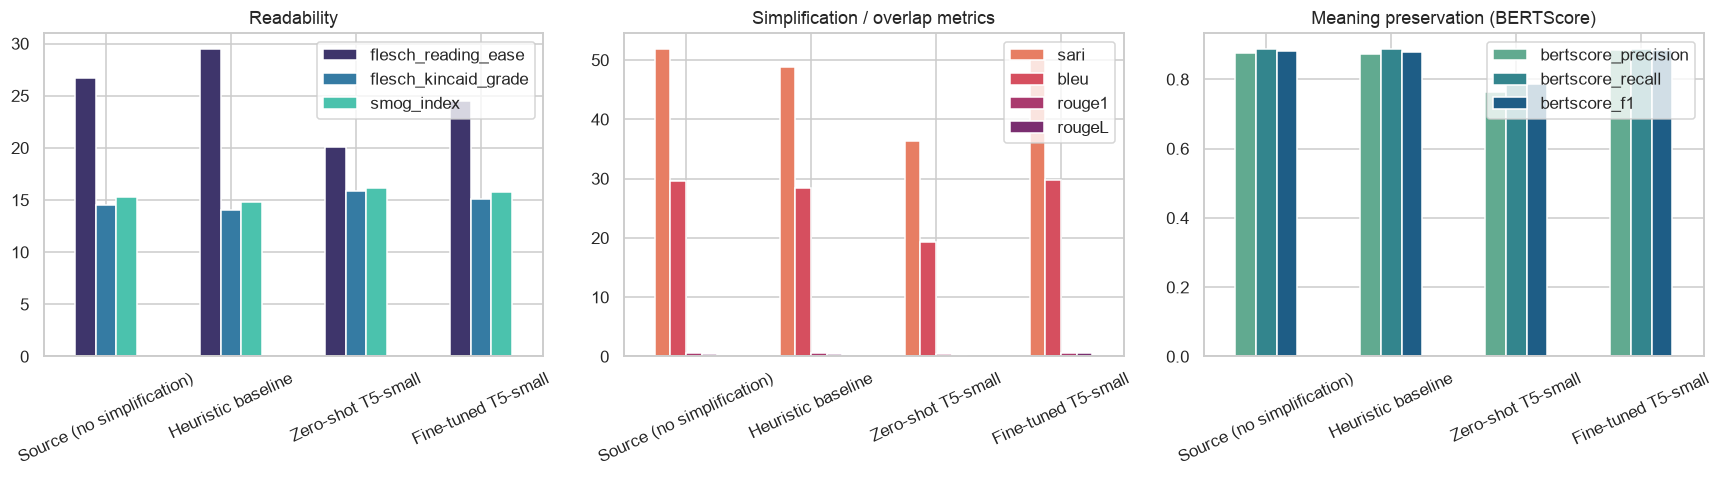

In [28]:
# --------------------------------------------------------------------
# Comparison charts
# --------------------------------------------------------------------
compare_systems = ["Source (no simplification)", "Heuristic baseline", "Zero-shot T5-small", "Fine-tuned T5-small"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

readability_cols = ["flesch_reading_ease", "flesch_kincaid_grade", "smog_index"]
results_df.loc[compare_systems, readability_cols].plot(kind="bar", ax=axes[0], color=sns.color_palette("mako", 3))
axes[0].set_title("Readability")
axes[0].tick_params(axis="x", rotation=25)

sari_bleu_cols = ["sari", "bleu", "rouge1", "rougeL"]
results_df.loc[compare_systems, sari_bleu_cols].plot(kind="bar", ax=axes[1], color=sns.color_palette("flare", 4))
axes[1].set_title("Simplification / overlap metrics")
axes[1].tick_params(axis="x", rotation=25)

bert_cols = ["bertscore_precision", "bertscore_recall", "bertscore_f1"]
results_df.loc[compare_systems, bert_cols].plot(kind="bar", ax=axes[2], color=sns.color_palette("crest", 3))
axes[2].set_title("Meaning preservation (BERTScore)")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_metric_comparison.png", dpi=150)
plt.show()


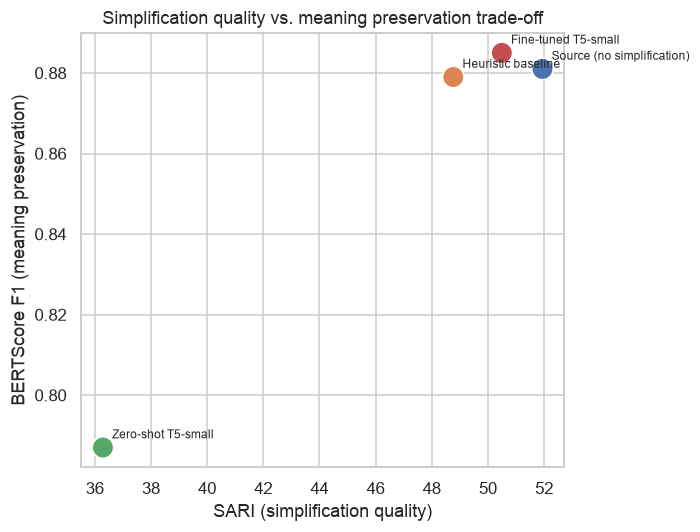

In [29]:
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.scatterplot(
    x=results_df.loc[compare_systems, "sari"],
    y=results_df.loc[compare_systems, "bertscore_f1"],
    hue=compare_systems, s=200, ax=ax, legend="full",
)
for name in compare_systems:
    ax.annotate(name, (results_df.loc[name, "sari"], results_df.loc[name, "bertscore_f1"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8)
ax.set_xlabel("SARI (simplification quality)")
ax.set_ylabel("BERTScore F1 (meaning preservation)")
ax.set_title("Simplification quality vs. meaning preservation trade-off")
ax.get_legend().remove()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_sari_vs_bertscore.png", dpi=150)
plt.show()


## 9. Qualitative Error Analysis

Automatic metrics are not treated as sufficient on their own. We inspect individual examples chosen to
represent a clearly improved case, a neutral case, and a distorted/failure case which are selected using
per-example BERTScore F1 (meaning preservation) and SARI (simplification quality) as a guide, then
read manually.


In [30]:
from bert_score import score as bertscore_score_per_example

_, _, per_example_f1 = bertscore_score_per_example(
    eval_df["finetuned_output"].tolist(), eval_df["simple"].tolist(),
    lang="en", model_type=CONFIG["bertscore_model_type"], verbose=False,
)
eval_df["finetuned_bertscore_f1"] = per_example_f1.numpy()

per_example_sari = [
    sari_metric.compute(sources=[s], predictions=[p], references=[[r]])["sari"]
    for s, p, r in zip(eval_df["complex"], eval_df["finetuned_output"], eval_df["simple"])
]
eval_df["finetuned_sari"] = per_example_sari

eval_df[["complex", "simple", "finetuned_output", "finetuned_sari", "finetuned_bertscore_f1"]].to_csv(
    TABLES_DIR / "per_example_scores.csv", index=False
)
eval_df.sort_values("finetuned_sari", ascending=False)[
    ["complex", "simple", "finetuned_output", "finetuned_sari", "finetuned_bertscore_f1"]
].head(5)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,complex,simple,finetuned_output,finetuned_sari,finetuned_bertscore_f1
100,Our review looked at one-month post-therapy ou...,Our review looked at one-month post-therapy ou...,Our review looked at one-month post-therapy ou...,100.0,1.0
113,More research is required using relatively che...,More research is required using relatively che...,More research is required using relatively che...,100.0,1.0
34,PFS was not reported in all of the studies but...,PFS was not reported in all of the studies but...,PFS was not reported in all of the studies but...,100.0,1.0
3,Health workers described working on the matern...,Health workers described working on the matern...,Health workers described working on the matern...,100.0,1.0
145,Studies assessing the effect of antidotes on o...,Studies assessing the effect of antidotes on o...,Studies assessing the effect of antidotes on o...,100.0,1.0


In [31]:
def show_example(row, title):
    print("=" * 100)
    print(title, f"(SARI={row['finetuned_sari']:.1f}, BERTScore-F1={row['finetuned_bertscore_f1']:.3f})")
    print("=" * 100)
    print("SOURCE (technical) :", row["complex"])
    print("REFERENCE (human)  :", row["simple"])
    print("HEURISTIC baseline :", row["heuristic_output"])
    print("ZERO-SHOT T5-small :", row["zeroshot_output"])
    print("FINE-TUNED T5-small:", row["finetuned_output"])
    print()

sorted_df = eval_df.sort_values("finetuned_sari", ascending=False).reset_index(drop=True)
n = len(sorted_df)

best_case = sorted_df.iloc[0]
neutral_case = sorted_df.iloc[n // 2]
worst_case = sorted_df.iloc[-1]

show_example(best_case, "STRONG CASE — high SARI / high meaning preservation")
show_example(neutral_case, "NEUTRAL / MIDDLE CASE")
show_example(worst_case, "WEAK CASE — low SARI and/or low meaning preservation")


STRONG CASE — high SARI / high meaning preservation (SARI=100.0, BERTScore-F1=1.000)
SOURCE (technical) : Our review looked at one-month post-therapy outcomes only.
REFERENCE (human)  : Our review looked at one-month post-therapy outcomes only.
HEURISTIC baseline : Our review looked at one-month post-therapy outcomes only.
ZERO-SHOT T5-small : simplify: Unser review simplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimplimpl
FINE-TUNED T5-small: Our review looked at one-month post-therapy outcomes only.

NEUTRAL / MIDDLE CASE (SARI=46.6, BERTScore-F1=0.831)
SOURCE (technical) : Therefore, we conducted no statistical analys

**Guided questions to answer in the write-up (based on the three examples above and a broader read of
`outputs/tables/per_example_scores.csv`):**

- Is meaning preserved in the strong case? Is anything clinically important quietly dropped?
- In the weak case, is the failure oversimplification, omission, distortion, or just awkward phrasing?
- Does the output become *shorter* without becoming genuinely *clearer*?
- Do failure patterns cluster around a particular sentence type (e.g. long statistical sentences,
  sentences with hedged/uncertain claims, negation)?


## 10. Discussion, Limitations, and Next Steps

**What this run demonstrates.** With `DEV_MODE = True`, this notebook trains on a small subset for a
few epochs purely to validate that the full pipeline. Data loading, cleaning, heuristic baseline,
zero-shot transformer baseline, fine-tuning, and the full metric suite all run correctly end-to-end and
produces genuine, inspectable outputs.

**Scaling up.** Set `DEV_MODE = False` in Section 1 and re-run the notebook to
train on the full ~7,000-pair Cochrane-auto sentence-level training set for up to `full_epochs` (8),
with early stopping on validation loss.

**Suggested extensions once the pipeline is validated:**

- Swap `CONFIG["model_name"]` to `"facebook/bart-base"` and re-run Section 7 to compare architectures.
- Increase `CONFIG["bertscore_model_type"]` to `"roberta-large"` (the model used in the original
  BERTScore paper) for the final reported numbers.
- Run the full test set (not a sample) for the numbers reported in the results chapter.
- Optionally load ASSET (`facebook/asset` on Hugging Face) purely as a metric-calibration sanity check.

**Ethical framing.** This pipeline is an assistive simplification
tool, not a medical decision system. The consistent gap (or lack of gap) between SARI/BLEU/ROUGE
readability gains and BERTScore/qualitative meaning preservation is itself a research finding and
identifying where automation is unsafe is as valuable as showing where it works.
